In [8]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
%matplotlib inline
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN

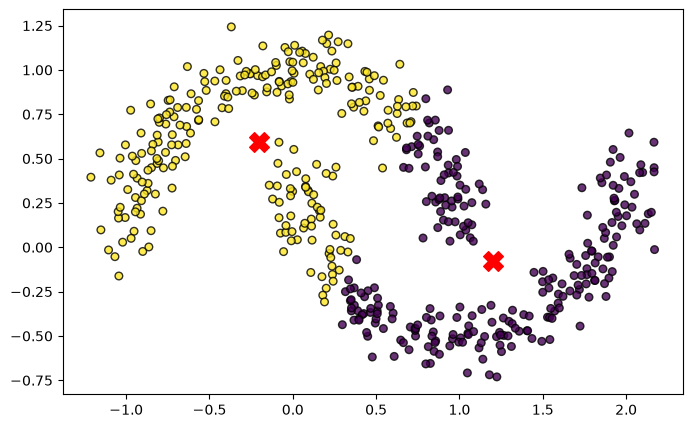

In [9]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=500, noise=0.1, random_state=42)
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
y_kmeans = kmeans.fit_predict(X)

plt.figure(figsize=(8, 5))
plt.scatter(
    X[:, 0],
    X[:, 1],
    c=y_kmeans,
    cmap="viridis",
    s=30,
    edgecolor="k",
    alpha=0.8,
)

centers = kmeans.cluster_centers_
plt.scatter(
    centers[:, 0],
    centers[:, 1],
    c="red",
    s=200,
    marker="X",
)

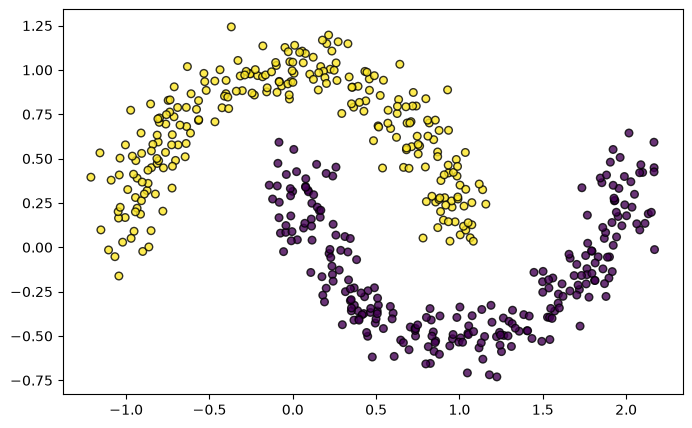

In [16]:
dbscan = DBSCAN(eps=0.2, min_samples=5)
y_dbscan = dbscan.fit_predict(X)
plt.figure(figsize=(8, 5))
plt.scatter(
    X[:, 0],
    X[:, 1],
    c=y_dbscan,
    cmap="viridis",
    s=30,
    edgecolor="k",
    alpha=0.8,
)

# exer 2

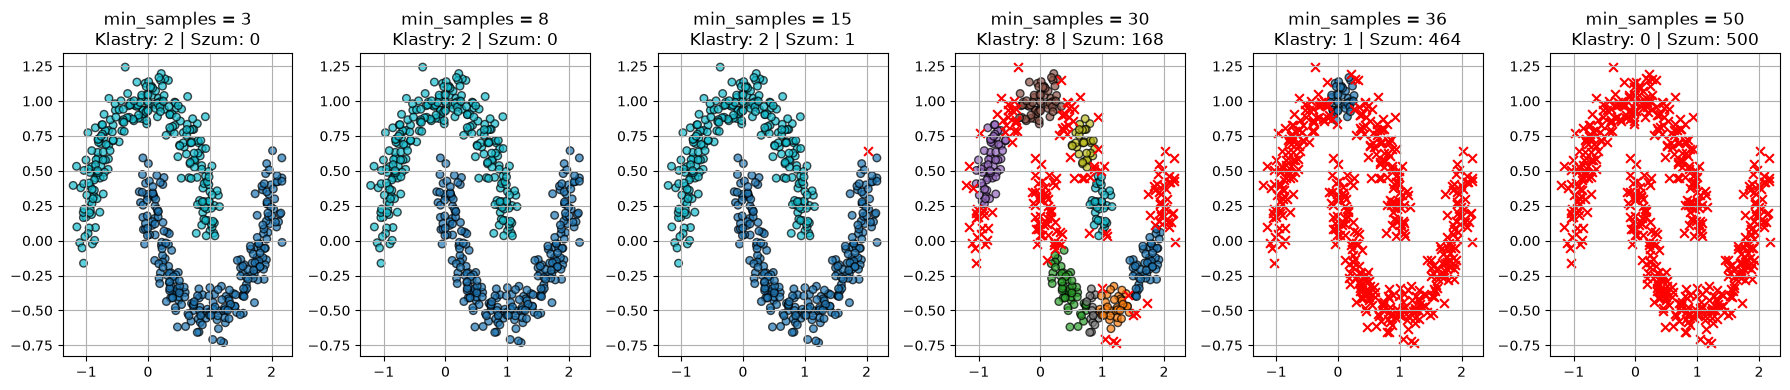

In [41]:
list_min_samples = [3, 8, 15, 30,36, 50]
fig, axes = plt.subplots(1, len(list_min_samples), figsize=(18, 4))

for ax, n_samples in zip(axes, list_min_samples):
    dbscan = DBSCAN(eps=0.2, min_samples=n_samples)
    labels = dbscan.fit_predict(X)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = np.sum(labels == -1)

    cluster_mask = labels != -1
    ax.scatter(
        X[cluster_mask, 0],
        X[cluster_mask, 1],
        c=labels[cluster_mask],
        cmap="tab10",
        s=30,
        edgecolor="k",
        alpha=0.7,
    )

    noise_mask = labels == -1
    ax.scatter(
        X[noise_mask, 0],
        X[noise_mask, 1],
        c="red",
        marker="x",
        s=40,
        label="Szum (-1)",
    )

    ax.set_title(
        f"min_samples = {n_samples}\nKlastry: {n_clusters} | Szum: {n_noise}"
    )
    ax.grid(True)

plt.tight_layout()
plt.show()

In [44]:
# min samples = 3 czyli lacza sie najblizsze 3 punkty - minimalna liczba punktow
# w promieniu epsilon
# min samples = 50 laczy sie 50 najblizszych punktow wiec mamy 0 klastrow

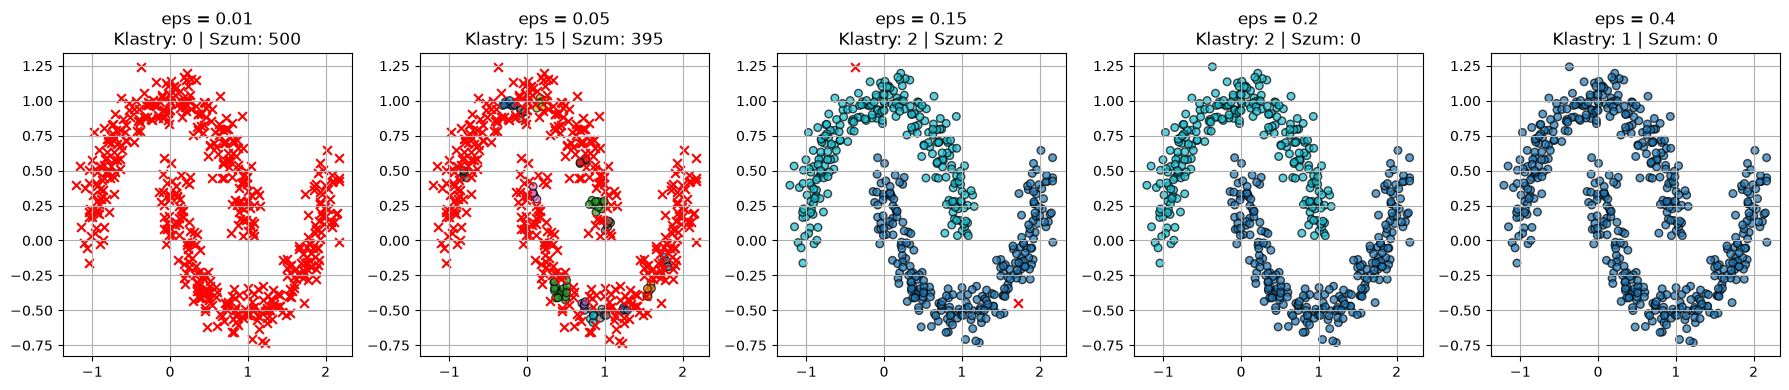

In [42]:
eps_list = [0.01, 0.05, 0.15, 0.2, 0.4]
fig, axes = plt.subplots(1, len(eps_list), figsize=(18, 4))

for ax, eps_val in zip(axes, eps_list):
    dbscan = DBSCAN(eps=eps_val, min_samples=5)
    labels = dbscan.fit_predict(X)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = np.sum(labels == -1)

    cluster_mask = labels != -1
    ax.scatter(
        X[cluster_mask, 0],
        X[cluster_mask, 1],
        c=labels[cluster_mask],
        cmap="tab10",
        s=30,
        edgecolor="k",
        alpha=0.7,
    )

    noise_mask = labels == -1
    ax.scatter(
        X[noise_mask, 0],
        X[noise_mask, 1],
        c="red",
        marker="x",
        s=40,
        label="Szum (-1)",
    )

    ax.set_title(
        f"eps = {eps_val}\nKlastry: {n_clusters} | Szum: {n_noise}"
    )
    ax.grid(True)

plt.tight_layout()
plt.show()

In [43]:
# eps 0.01 - zaden punkt nie ma liczby sasiadow w takim promieniu wiec klastrow mamy 0 
# eps 0.4 promien jest na tyle duzy ze lacza sie wszystkie punkty 